In [1]:
# 1. Thêm các thư viện cần thiết 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 2. Tải dữ liệu 
df = pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


RangeIndex(start=0, stop=303, step=1)


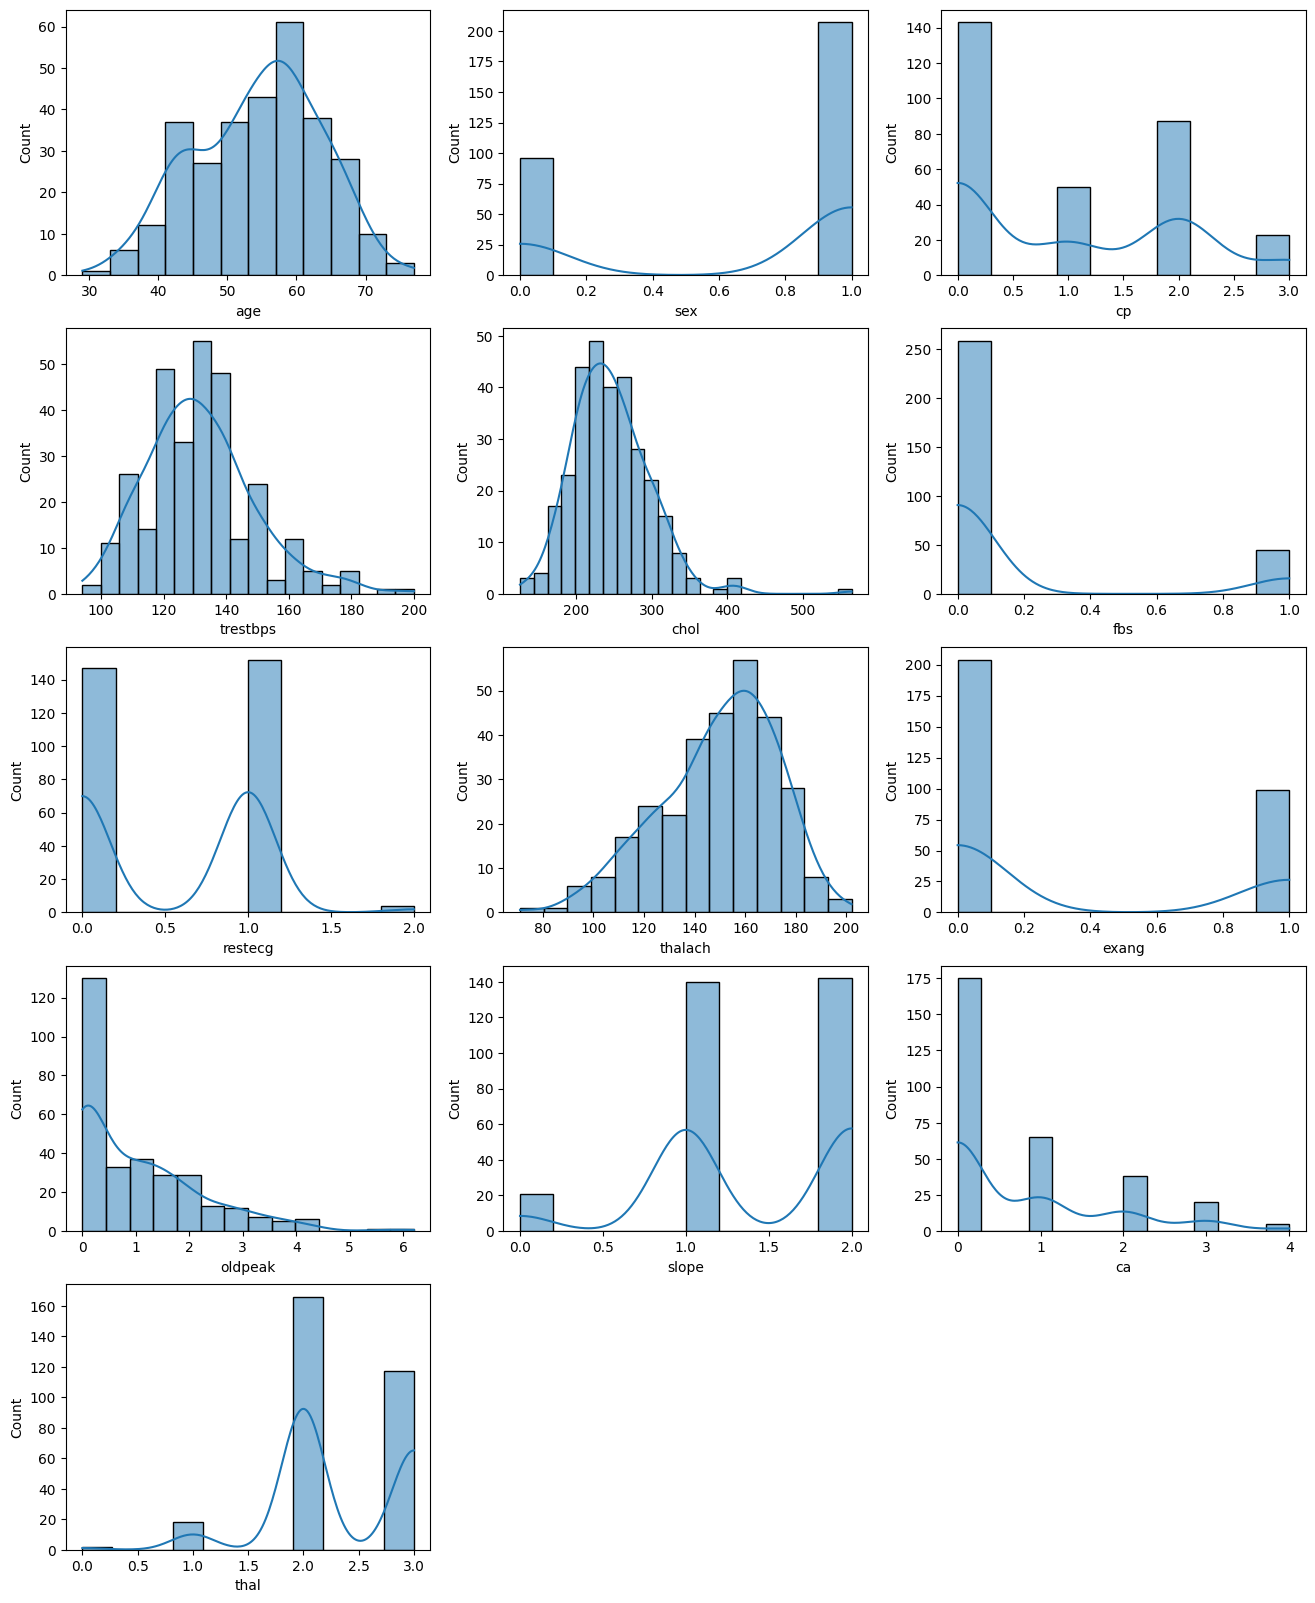

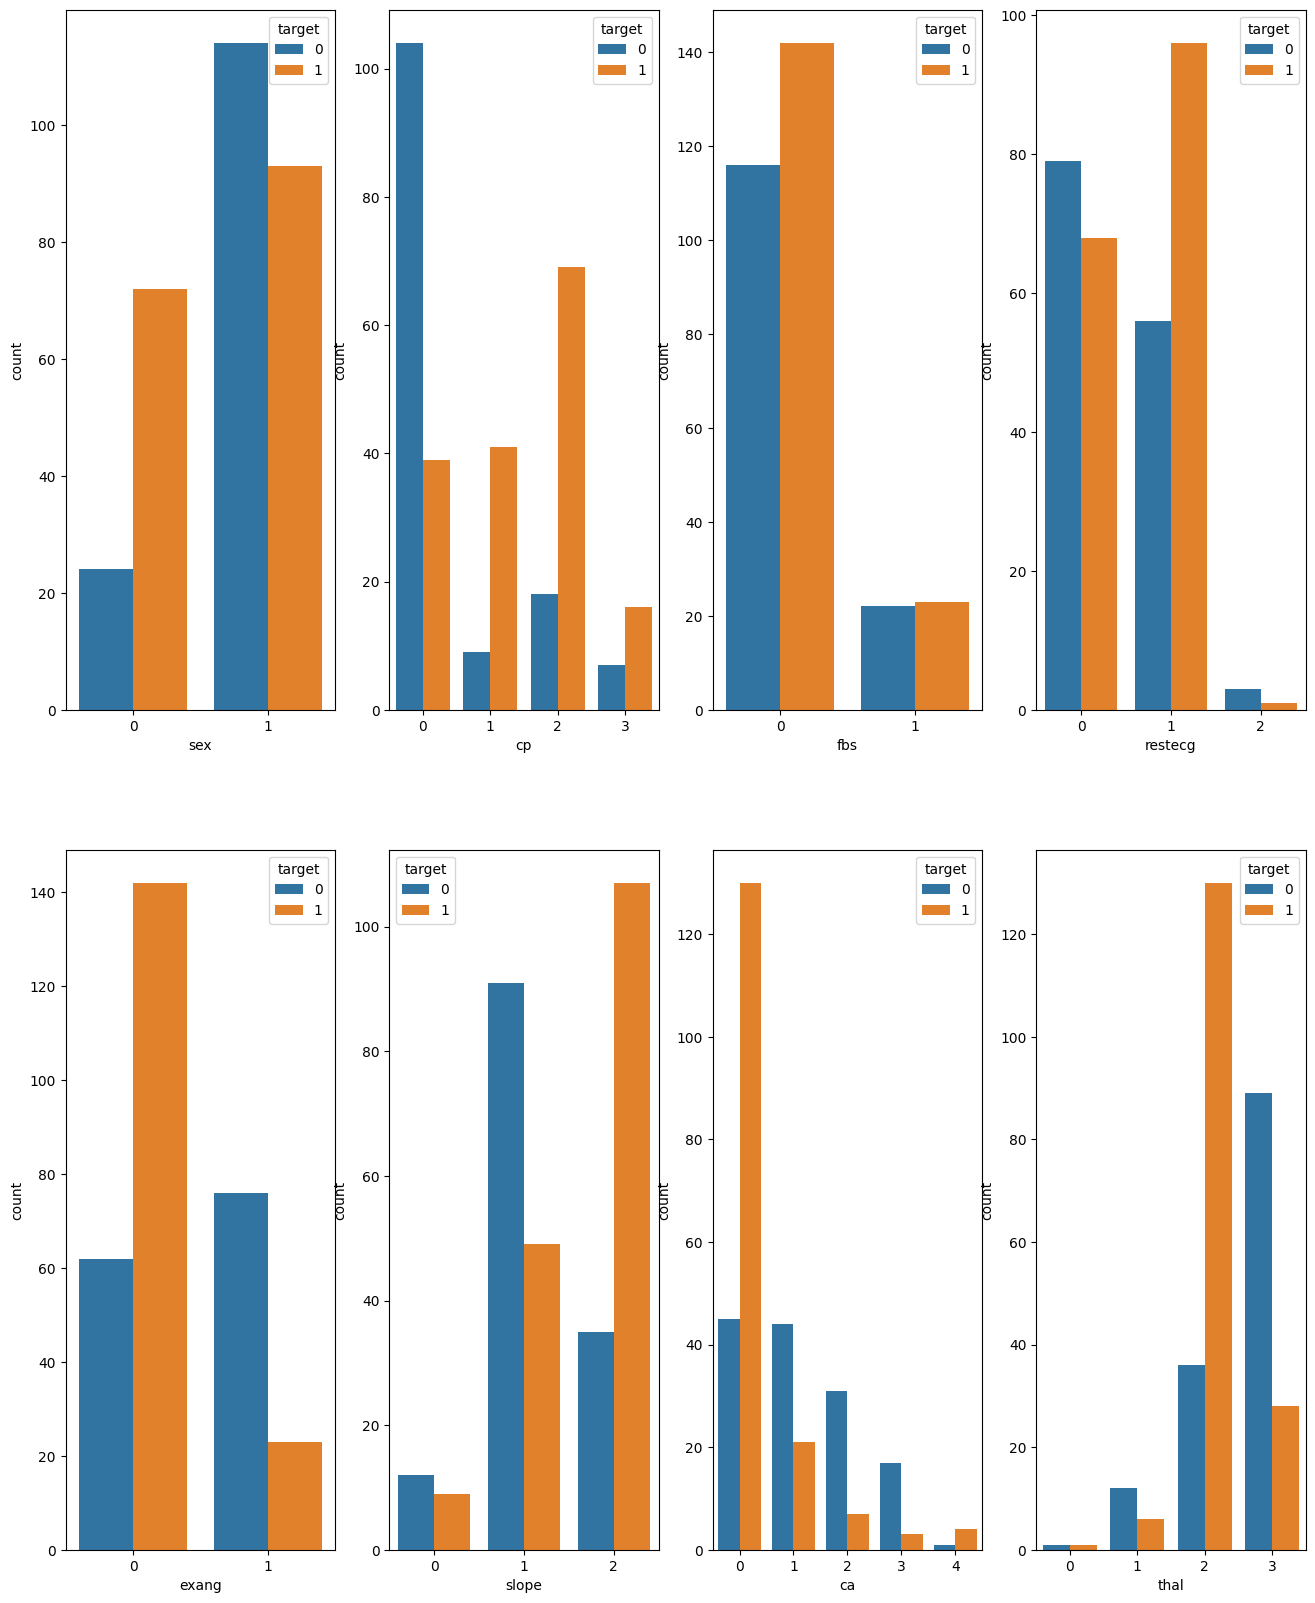

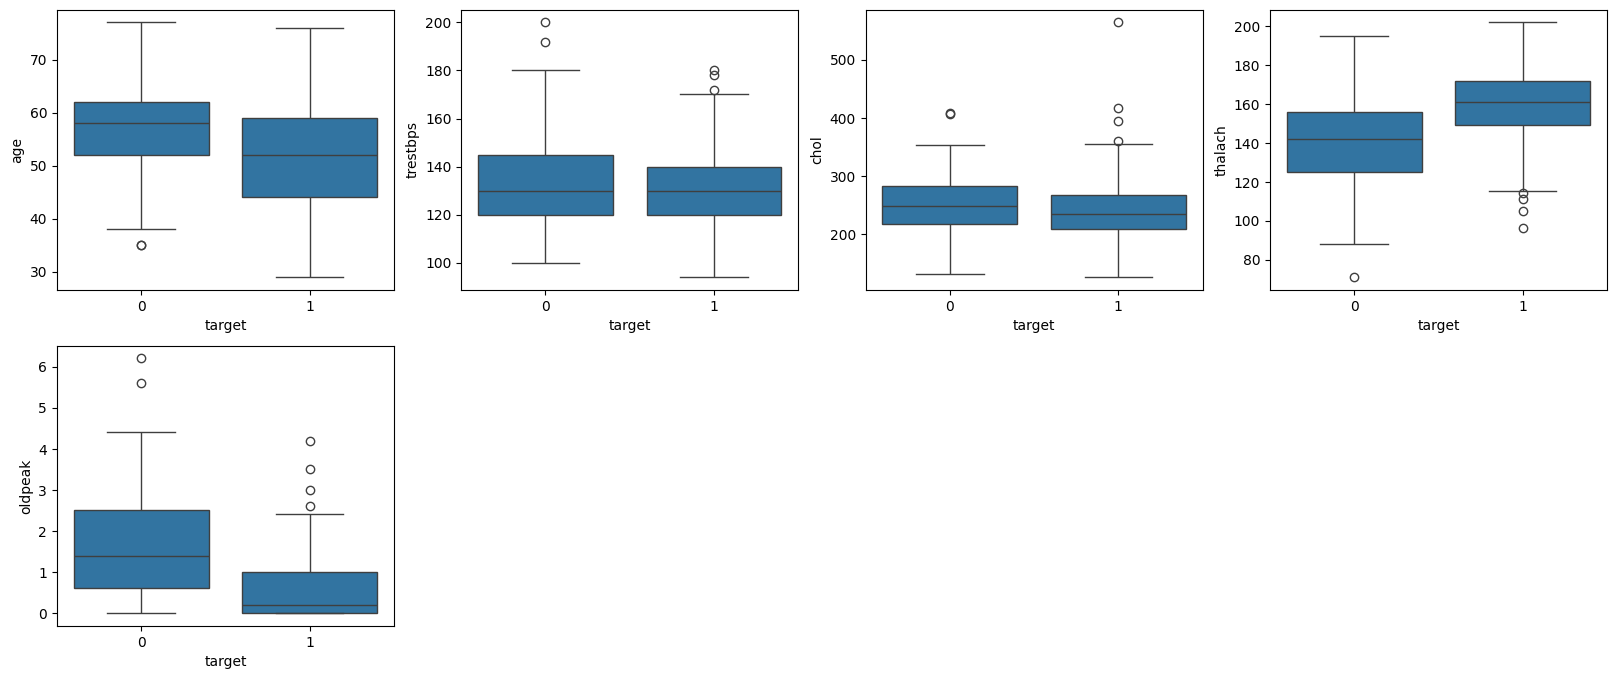

In [6]:
# 3. Tiến hành phân tích EDA các cột dữ liệu input 
# a. Hiển thị cách đánh index của dữ liệu 
print(df.index)
# b. Danh sách các cột input 
colunms_eda = df.columns[:-1]
colunms_eda
# c. Phân tích phân phối các biến số input 
fig = plt.figure(figsize=(16, 20))
for i in range(len(colunms_eda)):
   colname = colunms_eda[i]
   sub = fig.add_subplot(5, 3, i + 1)
   sns.histplot(df[colname], kde=True, ax=sub)
# d. Đếm xem số lượng các biến input (nhóm định tính) theo biến mục tiêu 
categories_list = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig = plt.figure(figsize=(16, 20))

for i in range(len(categories_list)):
    colname = categories_list[i]
    sub = fig.add_subplot(2, 4, i + 1)
    sns.countplot(x=colname, hue='target', data=df, ax=sub)
# e. Phân tích biểu đồ Box-plot các biến input (nhóm định lượng) theo biến mục tiêu
numerical_list = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig = plt.figure(figsize=(20, 8))

for i in range(len(numerical_list)):
    colname = numerical_list[i]
    sub = fig.add_subplot(2, 4, i + 1)
    sns.boxplot(x='target', y=colname, data=df, ax=sub)

[[42.  1.  1. ...  2.  0.  2.]
 [58.  1.  0. ...  2.  0.  3.]
 [46.  1.  2. ...  1.  0.  2.]
 ...
 [69.  1.  3. ...  1.  1.  2.]
 [46.  1.  0. ...  2.  0.  3.]
 [63.  0.  1. ...  2.  2.  2.]]
[[5.70e+01 1.00e+00 0.00e+00 1.50e+02 2.76e+02 0.00e+00 0.00e+00 1.12e+02
  1.00e+00 6.00e-01 1.00e+00 1.00e+00 1.00e+00]
 [5.90e+01 1.00e+00 3.00e+00 1.70e+02 2.88e+02 0.00e+00 0.00e+00 1.59e+02
  0.00e+00 2.00e-01 1.00e+00 0.00e+00 3.00e+00]
 [5.70e+01 1.00e+00 2.00e+00 1.50e+02 1.26e+02 1.00e+00 1.00e+00 1.73e+02
  0.00e+00 2.00e-01 2.00e+00 1.00e+00 3.00e+00]
 [5.60e+01 0.00e+00 0.00e+00 1.34e+02 4.09e+02 0.00e+00 0.00e+00 1.50e+02
  1.00e+00 1.90e+00 1.00e+00 2.00e+00 3.00e+00]
 [7.10e+01 0.00e+00 2.00e+00 1.10e+02 2.65e+02 1.00e+00 0.00e+00 1.30e+02
  0.00e+00 0.00e+00 2.00e+00 1.00e+00 2.00e+00]
 [5.70e+01 1.00e+00 2.00e+00 1.50e+02 1.68e+02 0.00e+00 1.00e+00 1.74e+02
  0.00e+00 1.60e+00 2.00e+00 0.00e+00 2.00e+00]
 [4.60e+01 0.00e+00 0.00e+00 1.38e+02 2.43e+02 0.00e+00 0.00e+00 1.52e+02
  

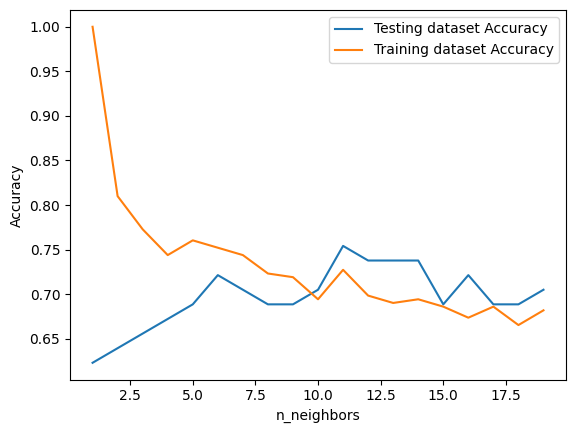

In [7]:
# 4. Xây dựng mô hình 
# a. Chuẩn bị dữ liệu 
x = df.iloc[:, :-1].values
y = df['target'].values
x = x.astype(float)
y = y.astype(float)
# b. Phân chia tập dữ liệu thành hai phần train và test tỉ lệ 80:20 và hệ số random là 42 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# c. Hiển thị danh sách index của các sample trong tập X_train, X_test 
print(X_train)
print(X_test)
# d. Huấn luyện mô hình 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=8,algorithm='ball_tree')
knn.fit(X_train, y_train)

# e. Đánh giá mô hình trên tập test bằng độ đo accuracy 
knn.score(X_test, y_test)
# f. 
# Sử dụng độ đo đánh giá accuracy trên tập train và test để so sánh và chọn lựa K bao 
# nhiêu là tốt nhất cho mô hình K-NN. Sinh viên nhìn biểu đồ để trả lời 
import numpy as np
neighbors = np.arange(1, 20)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracy[i] = knn.score(X_train, y_train)
    test_accuracy[i] = knn.score(X_test, y_test)

plt.plot(neighbors, test_accuracy, label='Testing dataset Accuracy')
plt.plot(neighbors, train_accuracy, label='Training dataset Accuracy')

plt.legend()
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.show()

In [8]:
# 5. Xây dựng lại mô hình với K là tốt nhất dựa trên câu 4f. Sau đó, sử dụng kết quả đó để giải 
# quyết từ câu 6 trở đi. 
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)



In [10]:
# 6. In ra danh sách khoảng cách và các hàng xóm từ các mẫu dữ liệu trong tập test từ mô hình 
# ở câu 5
distances, indices = knn.kneighbors(X_test)
print(distances)

[[ 6.63626401 17.93906352 18.22882333 23.23122898 24.27673784 27.23894271
  28.29416901 28.8159678 ]
 [20.96759404 21.51650529 26.15415837 27.35616932 27.89336839 28.93095228
  31.43580761 32.57299495]
 [46.55276576 46.92589903 53.2169146  54.00962877 54.00962877 54.46503466
  61.48788499 61.61980201]
 [15.49870962 18.20466973 18.77471704 56.31349749 58.30686066 58.89388763
  68.9890571  70.70509175]
 [14.45821566 18.65368596 23.08332732 23.13201245 23.40939982 25.0998008
  25.74878638 26.25718949]
 [18.4        21.65733132 23.94911272 23.94911272 27.62173058 29.97599039
  30.36511156 32.17530109]
 [ 7.07389567 12.38709005 14.         14.83239697 14.96529318 15.82276841
  16.53027525 18.24719156]
 [32.32274741 46.79059735 47.96873982 48.27007354 48.59269492 49.07504457
  51.07063736 52.13674328]
 [16.40853436 17.99555501 21.3541565  21.50441815 22.15152365 22.2135094
  22.737634   27.03701167]
 [12.77693234 13.9645981  14.08012784 14.67140075 15.18848248 15.5241747
  15.52707313 16.378

In [11]:
# 7. Cho biết sample input đầu tiên trong tập test sẽ lần lượt gần K (hàng xóm) dòng nào trong 
# tập train tính theo index và khoảng cách tương đương theo độ đo Euclidean là bao nhiêu? 
print(indices[0])
print(distances[0])

[  1  79 161 222 211  25 217 166]
[ 6.63626401 17.93906352 18.22882333 23.23122898 24.27673784 27.23894271
 28.29416901 28.8159678 ]


In [12]:
# 8. Cho biết với một sample input tương ứng ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
# 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'] = [47,0,0,150,250,0,1,140,1,0.5,1,0,2] thì sẽ 
# gần K hàng xóm nào trong tập huấn luyện, với tương ứng lần lượt khoảng cách là bao nhiêu 
# và cho biết giá trị Age của hàng xóm gần nhất. 
sample_input = np.array([[47,0,0,150,250,0,1,140,1,0.5,1,0,2]])
sample_input = sample_input.astype(float)
distances, indices = knn.kneighbors(sample_input)
print(indices)
print(distances)
print(X_train[indices[0][0]][0])


[[168   2 180  11  94  62 172 213]]
[[16.1322658  20.65453945 21.38340478 21.39649504 22.11537926 23.02194605
  23.09567059 23.23790008]]
61.0


In [13]:
# 9. Xem danh sách các giá trị của lớp đánh nhãn của biến output (target) nhằm xác định bệnh 
# nhân có bệnh hay không 
y_test


array([0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
       0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 0.])

In [14]:
# 10. Xem danh sách xác suất tiền dự báo của các mẫu dữ liệu tập test theo các nhãn đầu ra 

y_pred_prob = knn.predict_proba(X_test)
y_pred_prob


array([[1.   , 0.   ],
       [0.25 , 0.75 ],
       [0.375, 0.625],
       [0.375, 0.625],
       [0.625, 0.375],
       [0.25 , 0.75 ],
       [0.25 , 0.75 ],
       [0.75 , 0.25 ],
       [0.75 , 0.25 ],
       [0.25 , 0.75 ],
       [0.625, 0.375],
       [0.5  , 0.5  ],
       [0.125, 0.875],
       [0.625, 0.375],
       [0.125, 0.875],
       [0.25 , 0.75 ],
       [0.25 , 0.75 ],
       [0.5  , 0.5  ],
       [0.625, 0.375],
       [0.75 , 0.25 ],
       [0.5  , 0.5  ],
       [1.   , 0.   ],
       [0.75 , 0.25 ],
       [0.375, 0.625],
       [0.5  , 0.5  ],
       [0.25 , 0.75 ],
       [0.75 , 0.25 ],
       [0.   , 1.   ],
       [0.875, 0.125],
       [0.5  , 0.5  ],
       [0.875, 0.125],
       [0.875, 0.125],
       [0.875, 0.125],
       [0.125, 0.875],
       [0.75 , 0.25 ],
       [0.75 , 0.25 ],
       [0.25 , 0.75 ],
       [0.125, 0.875],
       [0.   , 1.   ],
       [0.   , 1.   ],
       [0.25 , 0.75 ],
       [0.25 , 0.75 ],
       [0.75 , 0.25 ],
       [0.1

In [15]:
# 11. Cho biết mẫu input thứ hai trong tập test  khi qua mô hình dự báo sẽ cho xác xuất dự báo 
# nhãn nào cao hơn và giá trị là bao nhiêu, còn nhãn thấp là nhãn nào có xác suất bao nhiêu 
print(y_pred_prob[1])
print(y_test[1])
print(y_pred[1])



[0.25 0.75]
0.0
1.0


In [16]:
# 12. Liệt kê danh sách các nhãn dự báo thông qua mô hình của các mẫu dữ liệu input trong tập 
# test. Hãy cho biết kết quả dự báo của mẫu input thứ 5 trong tập test sẽ được dự báo là bao 
# nhiêu?
y_test_pred = knn.predict(X_test)
print(y_test_pred)

[0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0.]


In [17]:
# 13. Hãy cho biết nếu điều chỉnh ngưỡng xác suất (threshold) đưa ra quyết định là 0.65 thì kết 
# quả dự báo của mẫu input số hai và mẫu số năm và mẫu số sáu là bao nhiêu 
y_pred_prob = knn.predict_proba(X_test)
y_pred_new = (y_pred_prob[:,1] >= 0.65).astype(int)
print(y_pred_new[1])
print(y_pred_new[5])
print(y_pred_new[6])



1
1
1


In [18]:
# 14. Hãy đánh giá mô hình trên tập test qua Confussion – Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[20  9]
 [10 22]]


In [19]:
# 15. Dựa vào confusion matrix, hãy cho biết giá trị quan trọng nhất trong bài toán dự báo này.
# Giải thích ý nghĩa của giá trị đó.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

         0.0       0.67      0.69      0.68        29
         1.0       0.71      0.69      0.70        32

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



In [20]:
# 16. Hãy đánh giá mô hình thông qua các giá trị Precision, Recall và F1 tổng quát. Trong bài 
# toán dự báo này thì đại lượng nào quan trọng.
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1: ', f1)



Precision:  0.7096774193548387
Recall:  0.6875
F1:  0.6984126984126984


In [21]:
# 17. Hãy in ra bảng báo cáo các đại lượng đánh giá theo từng nhóm giá trị nhãn đầu ra 
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.67      0.69      0.68        29
         1.0       0.71      0.69      0.70        32

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



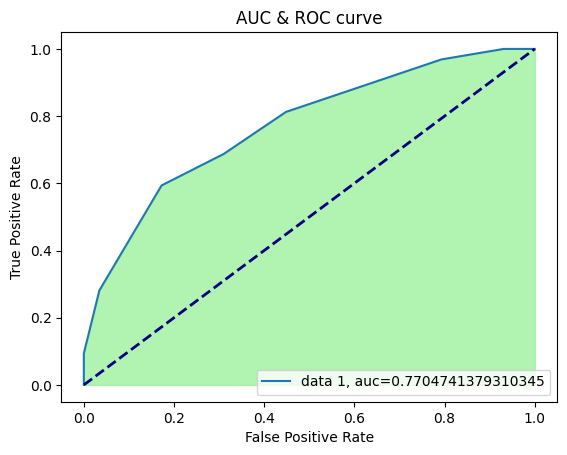

In [22]:
# 18. Đánh giá mô hình thông qua đồ thị AUC & ROC
y_pred_proba = knn.predict_proba(X_test)[::,1]
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('AUC & ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.fill_between(fpr, tpr, alpha=0.7, color='lightgreen')
plt.show()

[[24  5]
 [13 19]]
TPR:  0.59375
FNR:  0.40625
FPR:  0.1724137931034483
TNR:  0.8275862068965517
Precision:  0.7916666666666666
Recall:  0.59375
F1:  0.6785714285714286


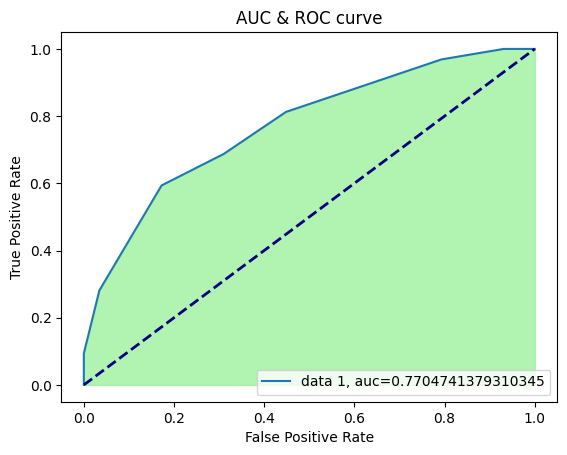

In [23]:
# 19. Hãy in ra màn hình accuracy, confusion matrix, [tn, fp, fn, tp], [TPR, FNR, FPR, TNR], 
# [precision, recal, F1] và đồ thị AUC & ROC với ngưỡng xác xuất phân lớp là 0.65. Đưa ra 
# kết luận khi thiết lập threshold tăng hoặc threshold giảm sẽ tác động như thế nào đến kết 
# quả đánh giá mô hình.
y_pred_prob = knn.predict_proba(X_test)
y_pred_new = (y_pred_prob[:,1] >= 0.65).astype(int)
cm = confusion_matrix(y_test, y_pred_new)
print(cm)
tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)
fnr = fn / (fn + tp)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print('TPR: ', tpr)
print('FNR: ', fnr)
print('FPR: ', fpr)
print('TNR: ', tnr)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1: ', f1)

y_pred_proba = knn.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('AUC & ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.fill_between(fpr, tpr, alpha=0.7, color='lightgreen')
plt.show()

In [24]:
# 20. Viết chương trình dự báo bệnh tim dưới dạng Console Application, cho phép người dùng 
# nhập các đặc trưng đầu vào (feature input) và ngưỡng xác suất (threshold, nếu không nhập 
# ngưỡng thì mặc định ngưỡng là 0.5). Sau đó, in ra kết quả chẩn đoán bệnh tim.

import numpy as np
from sklearn.linear_model import LogisticRegression

# Function to load or create a heart disease prediction model
def load_model():
    # For simplicity, we create a dummy model here
    model = LogisticRegression()
    # Dummy training data
    X_train = np.array([[45, 1, 3], [50, 0, 2], [60, 1, 1], [55, 0, 3]])
    y_train = np.array([1, 0, 1, 0])
    model.fit(X_train, y_train)
    return model

# Function to get user input for features and threshold
def get_user_input():
    age = int(input("Enter age: "))
    sex = int(input("Enter sex (1 for male, 0 for female): "))
    cp = int(input("Enter chest pain type (0-3): "))
    threshold = input("Enter threshold (default is 0.5): ")
    threshold = float(threshold) if threshold else 0.5
    return np.array([[age, sex, cp]]), threshold

# Function to make predictions based on the input features and threshold
def make_prediction(model, features, threshold):
    probability = model.predict_proba(features)[0][1]
    return probability >= threshold, probability

# Main function
def main():
    model = load_model()
    features, threshold = get_user_input()
    has_disease, probability = make_prediction(model, features, threshold)
    if has_disease:
        print(f"Heart disease predicted with probability {probability:.2f}")
    else:
        print(f"No heart disease predicted with probability {probability:.2f}")

if __name__ == "__main__":
    main()


Heart disease predicted with probability 0.81
